# M4.Ex2: Penguins Classification (PyCaret)

## Install & Patch PyCaret (Colab Python 3.12 fix)

> PyCaret blocks Python 3.12 at import time. This cell installs it and removes that check.

In [1]:
import subprocess
result = subprocess.run(['pip', 'show', 'pycaret'], capture_output=True, text=True)
location = [l.split(': ')[1] for l in result.stdout.splitlines() if l.startswith('Location')][0]
init_path = f"{location}/pycaret/__init__.py"

content = open(init_path).read()

# Disable the check by making the condition always False
patched = content.replace(
    'elif sys.version_info >= (3, 12):',
    'elif False:  # patched - 3.12 check disabled'
)
open(init_path, 'w').write(patched)
print("Patched.")

import importlib, pycaret
importlib.reload(pycaret)
print("PyCaret imported successfully:", pycaret.__version__)

Patched.
PyCaret imported successfully: 3.3.2


## Load the Data

In [1]:
import seaborn as sns
import pandas as pd

penguins = sns.load_dataset('penguins')
print(penguins.shape)
penguins.head()

(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:
# Quick overview
penguins.info()
print("\nMissing values:")
print(penguins.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


---
## Experiment 1
- **X**: `flipper_length_mm` (numerical), `bill_length_mm` (numerical)
- **y**: `species` (3-class categorical)

In [3]:
# Select relevant columns and drop rows with missing values
df1 = penguins[['flipper_length_mm', 'bill_length_mm', 'species']].dropna()
print(df1.shape)
df1.head()

(342, 3)


,flipper_length_mm,bill_length_mm,species
0,181.0,39.1,Adelie
1,186.0,39.5,Adelie
2,195.0,40.3,Adelie
4,193.0,36.7,Adelie
5,190.0,39.3,Adelie


In [4]:
from pycaret.classification import *

# Setup: initializes the ML pipeline (encoding, splitting, scaling)
exp1 = setup(
    data=df1,
    target='species',
    session_id=42,          # for reproducibility
    verbose=False
)

In [5]:
# Compare all available models and rank by Accuracy
best_models_1 = compare_models(n_select=3, sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9542,0.9926,0.9542,0.9604,0.9532,0.9274,0.9309,0.0680
lightgbm,Light Gradient Boosting Machine,0.9542,0.9923,0.9542,0.9595,0.9534,0.9279,0.9309,0.3810
qda,Quadratic Discriminant Analysis,0.9498,0.0000,0.9498,0.9555,0.9485,0.9205,0.9239,0.0250
rf,Random Forest Classifier,0.9458,0.9962,0.9458,0.9522,0.9452,0.9144,0.9178,0.2960
lr,Logistic Regression,0.9457,0.0000,0.9457,0.9521,0.9441,0.9138,0.9178,0.6200
knn,K Neighbors Classifier,0.9457,0.9776,0.9457,0.9521,0.9441,0.9138,0.9178,0.0430
lda,Linear Discriminant Analysis,0.9457,0.0000,0.9457,0.9521,0.9441,0.9138,0.9178,0.0270
nb,Naive Bayes,0.9455,0.9868,0.9455,0.9530,0.9430,0.9132,0.9181,0.0270
et,Extra Trees Classifier,0.9417,0.9967,0.9417,0.9485,0.9412,0.9082,0.9116,0.1500
ridge,Ridge Classifier,0.9413,0.0000,0.9413,0.9481,0.9387,0.9066,0.9112,0.0390


Processing:   0%|          | 0/67 [00:00<?, ?it/s]

In [6]:
# Pick the single best model
best1 = best_models_1[0]
print(type(best1))

<class 'xgboost.sklearn.XGBClassifier'>


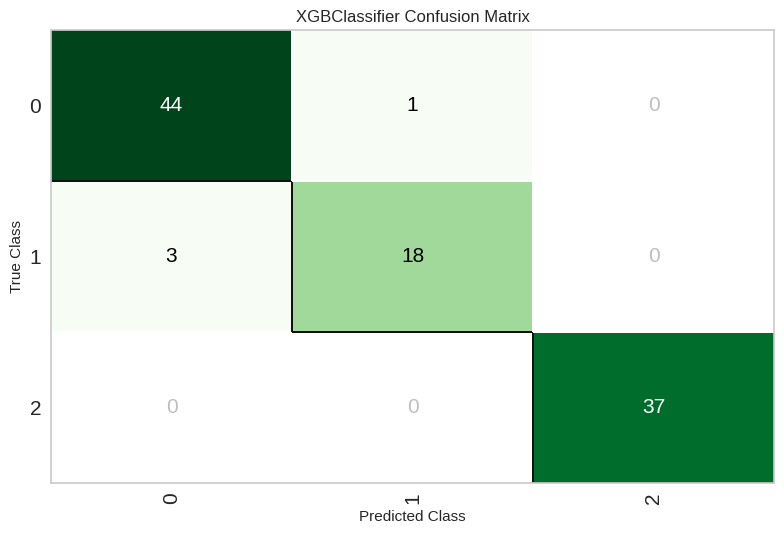

In [7]:
# Analyze: Confusion Matrix
plot_model(best1, plot='confusion_matrix')

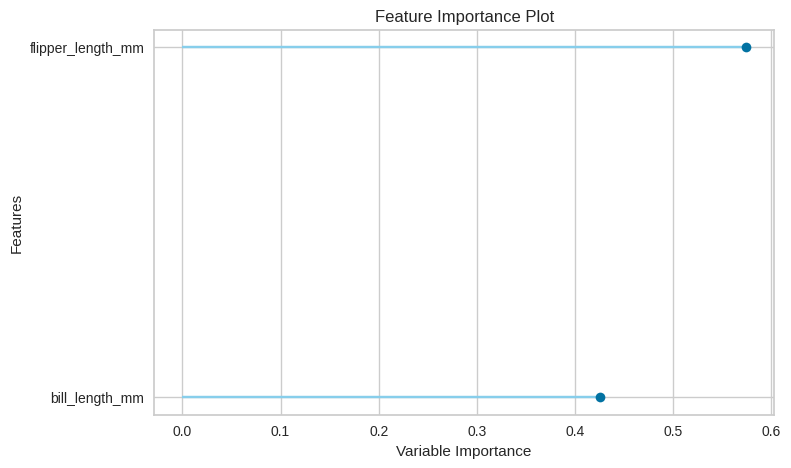

In [8]:
# Analyze: Feature Importance (not available for all models)
try:
    plot_model(best1, plot='feature')
except Exception as e:
    print(f"Feature importance not available for this model: {e}")

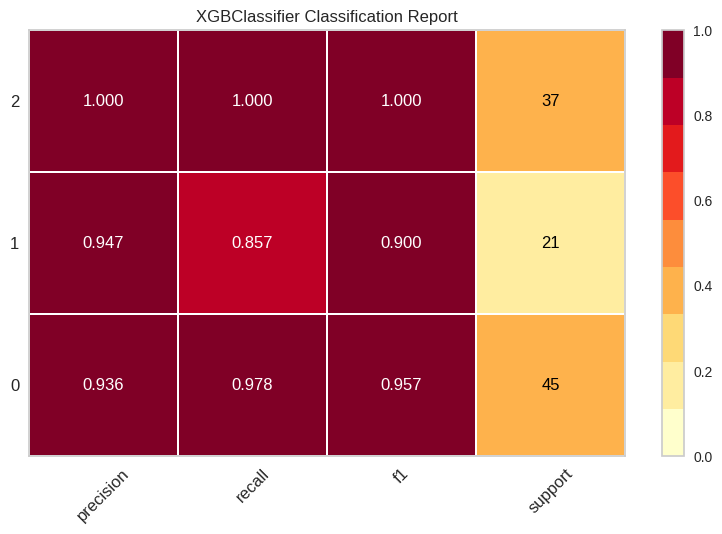

In [9]:
# Analyze: Class Report
plot_model(best1, plot='class_report')

In [10]:
# Predictions on the hold-out test set
predictions1 = predict_model(best1)
predictions1.head(10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.9612,0.9973,0.9612,0.9614,0.9606,0.9387,0.9393


,flipper_length_mm,bill_length_mm,species,prediction_label,prediction_score
131,197.0,43.099998,Adelie,Adelie,0.9855
278,208.0,43.200001,Gentoo,Gentoo,0.9866
211,194.0,45.599998,Chinstrap,Adelie,0.9551
22,189.0,35.900002,Adelie,Adelie,0.9984
15,185.0,36.599998,Adelie,Adelie,0.9973
317,222.0,46.900002,Gentoo,Gentoo,0.9995
263,216.0,49.599998,Gentoo,Gentoo,0.9968
236,210.0,42.000000,Gentoo,Gentoo,0.8873
119,189.0,41.099998,Adelie,Adelie,0.9979
286,214.0,46.200001,Gentoo,Gentoo,0.9995


In [11]:
# Predict on new (unseen) data
new_data1 = pd.DataFrame({
    'flipper_length_mm': [181, 210, 230],
    'bill_length_mm':    [39.1, 46.5, 55.0]
})
predict_model(best1, data=new_data1)

,flipper_length_mm,bill_length_mm,prediction_label,prediction_score
0,181,39.099998,Adelie,0.9973
1,210,46.500000,Gentoo,0.9942
2,230,55.000000,Gentoo,0.9976


In [12]:
# Save the model
save_model(best1, 'exp1_species_model')
print("Model saved: exp1_species_model.pkl")

Transformation Pipeline and Model Successfully Saved
Model saved: exp1_species_model.pkl


---
## Experiment 2
- **X**: `body_mass_g` (numerical), `species` (categorical)
- **y**: `sex` (binary categorical)

In [15]:
# Select relevant columns and drop missing values
df2 = penguins[['body_mass_g', 'species', 'sex']].dropna()
print(df2.shape)
print(df2['sex'].value_counts())
df2.head()

(333, 3)
sex
Male      168
Female    165
Name: count, dtype: int64


,body_mass_g,species,sex
0,3750.0,Adelie,Male
1,3800.0,Adelie,Female
2,3250.0,Adelie,Female
4,3450.0,Adelie,Female
5,3650.0,Adelie,Male


In [16]:
from pycaret.classification import *

exp2 = setup(
    data=df2,
    target='sex',
    session_id=42,
    verbose=False
)

In [17]:
best_models_2 = compare_models(n_select=3, sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.8587,0.9298,0.8587,0.8632,0.8584,0.7171,0.7215,0.0550
ada,Ada Boost Classifier,0.8545,0.9107,0.8545,0.8588,0.8541,0.7091,0.7132,0.1310
ridge,Ridge Classifier,0.8543,0.9291,0.8543,0.8579,0.8541,0.7084,0.7118,0.0550
lightgbm,Light Gradient Boosting Machine,0.8502,0.9110,0.8502,0.8569,0.8492,0.6997,0.7065,0.1100
lr,Logistic Regression,0.8415,0.9272,0.8415,0.8482,0.8407,0.6827,0.6892,0.0690
gbc,Gradient Boosting Classifier,0.8114,0.8983,0.8114,0.8195,0.8100,0.6218,0.6300,0.1360
xgboost,Extreme Gradient Boosting,0.7989,0.8996,0.7989,0.8055,0.7978,0.5970,0.6036,0.1360
rf,Random Forest Classifier,0.7986,0.8860,0.7986,0.8073,0.7970,0.5962,0.6049,0.2100
et,Extra Trees Classifier,0.7904,0.8277,0.7904,0.7965,0.7890,0.5800,0.5861,0.2060
knn,K Neighbors Classifier,0.7855,0.8414,0.7855,0.8052,0.7824,0.5704,0.5894,0.0660


Processing:   0%|          | 0/67 [00:00<?, ?it/s]

In [18]:
best2 = best_models_2[0]
print(type(best2))

<class 'sklearn.discriminant_analysis.LinearDiscriminantAnalysis'>


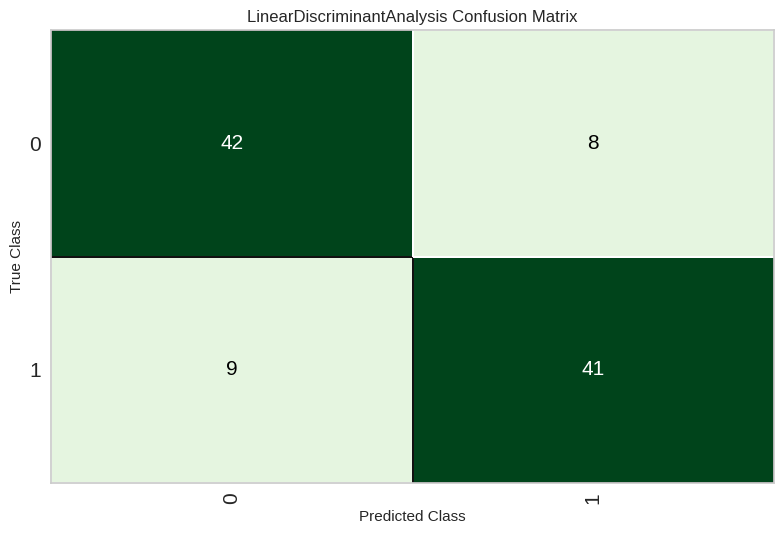

In [19]:
plot_model(best2, plot='confusion_matrix')

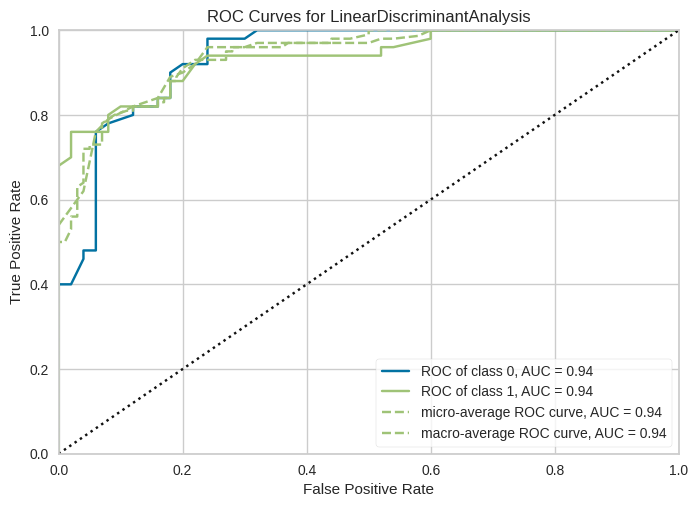

In [20]:
# ROC-AUC curve (binary classification)
plot_model(best2, plot='auc')

In [21]:
predictions2 = predict_model(best2)
predictions2.head(10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.8300,0.9364,0.8300,0.8301,0.8300,0.6600,0.6601


,body_mass_g,species,sex,prediction_label,prediction_score
150,3700.0,Adelie,Female,Male,0.5418
107,3900.0,Adelie,Male,Male,0.8208
7,4675.0,Adelie,Male,Male,0.9989
268,5100.0,Gentoo,Female,Male,0.5513
32,3300.0,Adelie,Female,Female,0.9269
285,5700.0,Gentoo,Male,Male,0.9862
277,5000.0,Gentoo,Male,Female,0.6157
124,3050.0,Adelie,Female,Female,0.9857
44,3000.0,Adelie,Female,Female,0.9898
281,5300.0,Gentoo,Male,Male,0.8264


In [22]:
new_data2 = pd.DataFrame({
    'body_mass_g': [3500, 5200, 4000],
    'species':     ['Adelie', 'Gentoo', 'Chinstrap']
})
predict_model(best2, data=new_data2)

,body_mass_g,species,prediction_label,prediction_score
0,3500,Adelie,Female,0.7661
1,5200,Gentoo,Male,0.7074
2,4000,Chinstrap,Male,0.8683


In [23]:
save_model(best2, 'exp2_sex_model')
print("Model saved: exp2_sex_model.pkl")

Transformation Pipeline and Model Successfully Saved
Model saved: exp2_sex_model.pkl


---
## Experiment 3 — Multi-Label Classification
- **X**: `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
- **y**: `sex` AND `species` (multi-label)

> **Note**: PyCaret's classification module handles one target at a time. For multi-label classification we train one model per target and combine predictions. This is the **Binary Relevance** approach.

In [24]:
# Features shared by both sub-models
features = ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

df3 = penguins[features + ['species', 'sex']].dropna()
print(df3.shape)
df3.head()

(333, 7)


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species,sex
0,Torgersen,39.1,18.7,181.0,3750.0,Adelie,Male
1,Torgersen,39.5,17.4,186.0,3800.0,Adelie,Female
2,Torgersen,40.3,18.0,195.0,3250.0,Adelie,Female
4,Torgersen,36.7,19.3,193.0,3450.0,Adelie,Female
5,Torgersen,39.3,20.6,190.0,3650.0,Adelie,Male


### 3a — Predict `species`

In [25]:
from pycaret.classification import *

df3_species = df3[features + ['species']]

exp3a = setup(
    data=df3_species,
    target='species',
    session_id=42,
    verbose=False
)

In [26]:
best3a = compare_models(sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.9913,0.0000,0.9913,0.9921,0.9910,0.9863,0.9869,0.0630
lda,Linear Discriminant Analysis,0.9913,0.0000,0.9913,0.9921,0.9910,0.9863,0.9869,0.0550
lr,Logistic Regression,0.9871,0.0000,0.9871,0.9890,0.9872,0.9801,0.9809,0.2120
rf,Random Forest Classifier,0.9870,0.9993,0.9870,0.9888,0.9870,0.9798,0.9807,0.3410
et,Extra Trees Classifier,0.9870,0.9994,0.9870,0.9874,0.9868,0.9796,0.9799,0.1840
lightgbm,Light Gradient Boosting Machine,0.9870,1.0000,0.9870,0.9885,0.9868,0.9796,0.9805,0.4100
gbc,Gradient Boosting Classifier,0.9828,0.0000,0.9828,0.9836,0.9827,0.9729,0.9735,0.3620
xgboost,Extreme Gradient Boosting,0.9826,0.9991,0.9826,0.9834,0.9823,0.9727,0.9733,0.1550
dt,Decision Tree Classifier,0.9786,0.9846,0.9786,0.9805,0.9788,0.9667,0.9675,0.0560
ada,Ada Boost Classifier,0.9310,0.0000,0.9310,0.9459,0.9263,0.8907,0.8999,0.1380


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

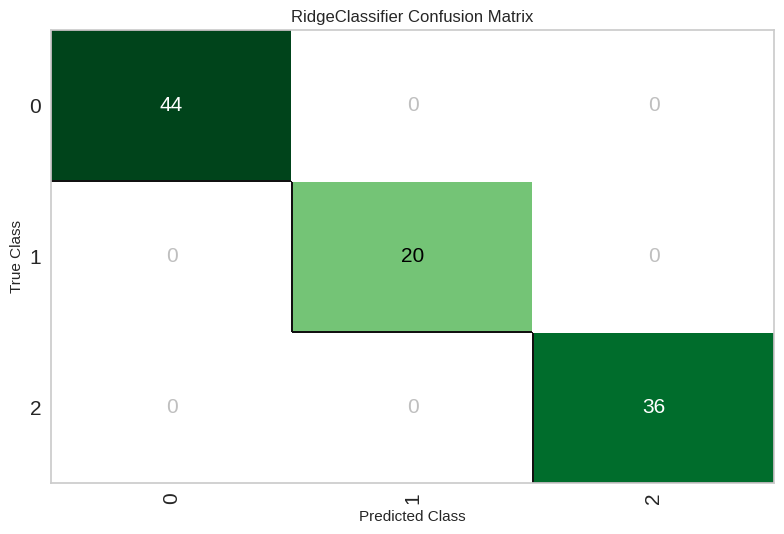

In [27]:
plot_model(best3a, plot='confusion_matrix')

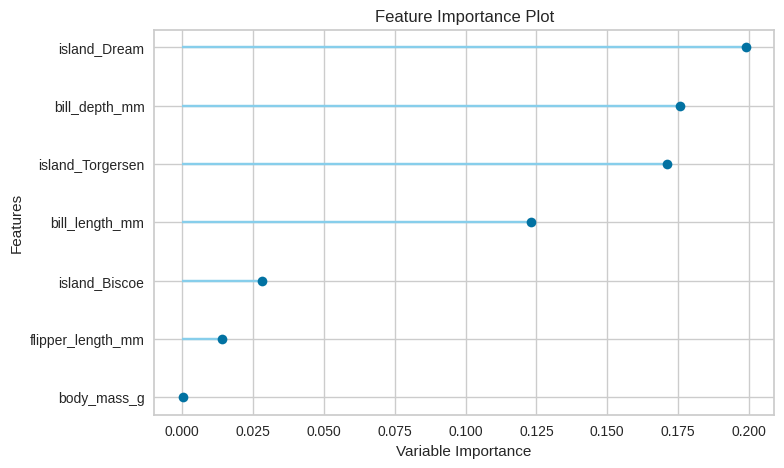

In [28]:
try:
    plot_model(best3a, plot='feature')
except Exception as e:
    print(f"Feature importance not available: {e}")

In [29]:
preds3a = predict_model(best3a)
preds3a.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,1.0000,0,1.0000,1.0000,1.0000,1.0000,1.0000


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species,prediction_label
194,Dream,50.900002,19.1,196.0,3550.0,Chinstrap,Chinstrap
235,Biscoe,49.299999,15.7,217.0,5850.0,Gentoo,Gentoo
289,Biscoe,50.700001,15.0,223.0,5550.0,Gentoo,Gentoo
308,Biscoe,47.500000,14.0,212.0,4875.0,Gentoo,Gentoo
81,Torgersen,42.900002,17.6,196.0,4700.0,Adelie,Adelie


In [30]:
save_model(best3a, 'exp3a_species_full_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['bill_length_mm', 'bill_depth_mm',
                                              'flipper_length_mm',
                                              'body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,...
                  TransformerWrapper(exclude=None, include=['island'],
                                     transformer=OneHotEncoder(cols=['island'],
                                                               drop_invariant=

### 3b — Predict `sex`

In [31]:
from pycaret.classification import *

df3_sex = df3[features + ['sex']]

exp3b = setup(
    data=df3_sex,
    target='sex',
    session_id=42,
    verbose=False
)

In [32]:
best3b = compare_models(sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9183,0.9792,0.9183,0.9252,0.9174,0.8356,0.8427,0.1830
lr,Logistic Regression,0.9143,0.9617,0.9143,0.9180,0.9141,0.8281,0.8319,0.1400
ridge,Ridge Classifier,0.9058,0.9609,0.9058,0.9106,0.9054,0.8110,0.8159,0.0600
lda,Linear Discriminant Analysis,0.9058,0.9609,0.9058,0.9106,0.9054,0.8110,0.8159,0.0580
ada,Ada Boost Classifier,0.9053,0.9588,0.9053,0.9095,0.9049,0.8101,0.8144,0.1440
xgboost,Extreme Gradient Boosting,0.9051,0.9737,0.9051,0.9093,0.9047,0.8094,0.8139,0.0760
lightgbm,Light Gradient Boosting Machine,0.9005,0.9724,0.9005,0.9060,0.9000,0.8001,0.8059,0.1170
gbc,Gradient Boosting Classifier,0.8920,0.9744,0.8920,0.8960,0.8917,0.7835,0.7875,0.1670
rf,Random Forest Classifier,0.8837,0.9709,0.8837,0.8903,0.8830,0.7662,0.7731,0.2810
dt,Decision Tree Classifier,0.8799,0.8788,0.8799,0.8903,0.8790,0.7593,0.7697,0.0600


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

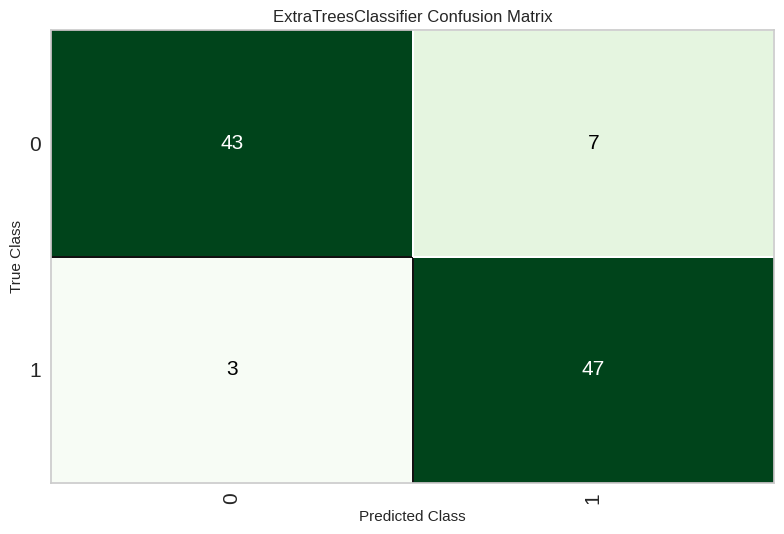

In [33]:
plot_model(best3b, plot='confusion_matrix')

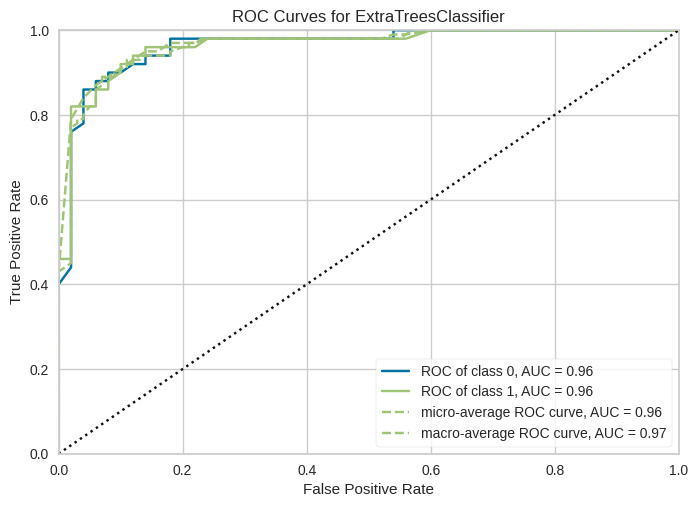

In [34]:
plot_model(best3b, plot='auc')

In [35]:
preds3b = predict_model(best3b)
preds3b.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9000,0.9636,0.9000,0.9026,0.8998,0.8000,0.8026


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,prediction_label,prediction_score
150,Dream,36.000000,17.100000,187.0,3700.0,Female,Female,0.61
107,Biscoe,38.200001,20.000000,190.0,3900.0,Male,Male,0.88
7,Torgersen,39.200001,19.600000,195.0,4675.0,Male,Male,0.97
268,Biscoe,44.900002,13.300000,213.0,5100.0,Female,Female,0.86
32,Dream,39.500000,17.799999,188.0,3300.0,Female,Female,0.93


In [36]:
save_model(best3b, 'exp3b_sex_full_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['bill_length_mm', 'bill_depth_mm',
                                              'flipper_length_mm',
                                              'body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                                       class_weight=None, criterion='gini',
                                       max_depth=None, max_features='sqrt',
      

### Combined Multi-Label Prediction

In [45]:
new_data3 = pd.DataFrame({
    'island':            ['Biscoe', 'Dream', 'Torgersen'],
    'bill_length_mm':    [45.0, 39.5, 50.0],
    'bill_depth_mm':     [15.0, 17.0, 18.5],
    'flipper_length_mm': [210.0, 190.0, 200.0],
    'body_mass_g':       [5000.0, 3500.0, 4200.0]
})

# Use get_config to retrieve the full pipeline and predict through it
from pycaret.classification import get_config

pipeline3a = get_config('pipeline')  # gets the active experiment's pipeline

# Re-run setups to get each pipeline explicitly
exp3a = setup(data=df3[['island','bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','species']], target='species', session_id=42, verbose=False)
pred_species = predict_model(best3a, data=new_data3)[['prediction_label']].rename(columns={'prediction_label': 'pred_species'})

exp3b = setup(data=df3[['island','bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']], target='sex', session_id=42, verbose=False)
pred_sex = predict_model(best3b, data=new_data3)[['prediction_label']].rename(columns={'prediction_label': 'pred_sex'})

result = pd.concat([new_data3.reset_index(drop=True), pred_species.reset_index(drop=True), pred_sex.reset_index(drop=True)], axis=1)
result

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,pred_species,pred_sex
0,Biscoe,45.0,15.0,210.0,5000.0,Gentoo,Female
1,Dream,39.5,17.0,190.0,3500.0,Adelie,Female
2,Torgersen,50.0,18.5,200.0,4200.0,Chinstrap,Male


---
## Summary

| Experiment | Features | Target | Approach |
|---|---|---|---|
| 1 | `flipper_length_mm`, `bill_length_mm` | `species` | Multi-class |
| 2 | `body_mass_g`, `species` | `sex` | Binary |
| 3 | `island`, 4 measurements | `species` + `sex` | Multi-label (Binary Relevance) |

Each experiment followed the PyCaret workflow: **Setup → Compare Models → Analyze → Predict → Save**.